In [1]:
import pdal
import geopandas as gpd
import json
import pandas as pd
import numpy as np
from shapely import MultiPoint
import shapely
from buildingregulariser import regularize_geodataframe
import warnings
import math
import os
# import rasterio
# import rioxarray
from osgeo import gdal
from shapely.geometry import Polygon, MultiPolygon, LinearRing, box
from shapely.ops import unary_union, polygonize
import swifter

/Users/fernandogomes/miniconda3/envs/pdal/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
RESULT_FOLDER = '/Users/fernandogomes/dev/LiDAR_produtos'

In [3]:
resolution = 0.5
gdf_distritos = gpd.read_file('data/SIRGAS_GPKG_distrito.gpkg')
gdf_articulacao_17_20 = gpd.read_file("zip://data/SIRGAS_SHP_quadriculamdt.zip!/SIRGAS_SHP_quadriculamdt/")
gdf_articulacao_24 = gpd.read_file('results/folhas_sp_cortada.gpkg')
gdf_articulacao_24.to_crs(epsg=31983, inplace=True)

In [4]:
gdf_folhas = gdf_articulacao_24.overlay(gdf_distritos[gdf_distritos.ds_nome == 'BELEM'])

In [5]:
folhas = [f'{RESULT_FOLDER}/2024/BHM/BHM-{nome}-2024-50cm.tiff' for nome in gdf_folhas.nome.to_list()]

In [6]:
' '.join(folhas)

'/Users/fernandogomes/dev/LiDAR_produtos/2024/BHM/BHM-Y-C-VI-2-NE-C-I-2-2024-50cm.tiff /Users/fernandogomes/dev/LiDAR_produtos/2024/BHM/BHM-Y-C-VI-2-NE-A-III-5-2024-50cm.tiff /Users/fernandogomes/dev/LiDAR_produtos/2024/BHM/BHM-Y-C-VI-2-NE-A-III-2-2024-50cm.tiff /Users/fernandogomes/dev/LiDAR_produtos/2024/BHM/BHM-Y-C-VI-2-NE-C-I-3-2024-50cm.tiff /Users/fernandogomes/dev/LiDAR_produtos/2024/BHM/BHM-Y-C-VI-2-NE-A-III-6-2024-50cm.tiff /Users/fernandogomes/dev/LiDAR_produtos/2024/BHM/BHM-Y-C-VI-2-NE-A-III-3-2024-50cm.tiff /Users/fernandogomes/dev/LiDAR_produtos/2024/BHM/BHM-Y-C-VI-2-NE-C-II-4-2024-50cm.tiff /Users/fernandogomes/dev/LiDAR_produtos/2024/BHM/BHM-Y-C-VI-2-NE-C-II-1-2024-50cm.tiff /Users/fernandogomes/dev/LiDAR_produtos/2024/BHM/BHM-Y-C-VI-2-NE-A-IV-4-2024-50cm.tiff /Users/fernandogomes/dev/LiDAR_produtos/2024/BHM/BHM-Y-C-VI-2-NE-A-IV-1-2024-50cm.tiff /Users/fernandogomes/dev/LiDAR_produtos/2024/BHM/BHM-Y-C-VI-2-NE-C-II-5-2024-50cm.tiff /Users/fernandogomes/dev/LiDAR_produtos/

In [7]:
!gdalbuildvrt temp/BHM-bras.vrt {' '.join(folhas)}

0...10...20...30...40...50...60...70...80...90...100 - done.


In [8]:
!gdal_translate temp/BHM-bras.vrt temp/BHM-bras.tiff

Input file size is 8610, 9252
0...10...20...30...40...50...60...70...80...90...100 - done.


In [9]:
def get_coordenadas():
    ds = gdal.Open("temp/BHM-bras.tiff")
    gt = ds.GetGeoTransform()

    cols = ds.RasterXSize
    rows = ds.RasterYSize

    minx = gt[0]
    maxy = gt[3]
    maxx = minx + cols * gt[1]
    miny = maxy + rows * gt[5]

    return [minx, miny, maxx, maxy]

In [10]:
gdf_quadras = gpd.read_file('data/SIRGAS_GPKG_quadraviariaed_2017.gpkg')
so_quadra = gdf_quadras.qe_tipo == 'Quadra'
gdf_quadras = gdf_quadras[so_quadra].reset_index()
gdf_quadras.geometry = gdf_quadras.buffer(2)
# gdf_quadras = gdf_quadras.overlay(gdf_distritos[gdf_distritos.ds_nome == 'BRAS'])
gdf_quadras = gdf_quadras.overlay(gpd.GeoDataFrame(geometry=[box(*get_coordenadas())], crs="EPSG:31983"))
gdf_quadras.to_file('data/quadras_viarias.gpkg')


In [11]:
' '.join([str(x) for x in get_coordenadas()])

'335161.5 7393304.5 339466.5 7397930.5'

In [12]:
!gdal_rasterize -burn 1.0 -tr 0.5 0.5 -a_nodata 0.0 -te {' '.join([str(x) for x in get_coordenadas()])} -ot Float32 -of GTiff data/quadras_viarias.gpkg  temp/quadras_viarias.tiff

0...10...20...30...40...50...60...70...80...90...100 - done.


In [13]:
!gdal_calc.py -A temp/quadras_viarias.tiff -B temp/BHM-bras.tiff --outfile=temp/BHM-bras.tiff --calc="A*B" --NoDataValue=0 --overwrite


0...10...20...30...40...50...60...70...80...90...100 - done.


In [14]:
def laz_pipeline(resolution):
    return [
        {
            "type":"readers.las",
            "filename":f"/Users/fernandogomes/dev/LiDAR_produtos/2024/LiDAR-subs/10-BELEM-buildings-50cm.laz"
        },
        {
            "type":"filters.dbscan",
            "min_points":5,
            "eps": 0.5 * math.sqrt(2),
            "dimensions":"X,Y,Z",
            # "eps": 0.5 * 2,
        },
    ]

In [15]:
def laz_pipeline(resolution):
    return [
        {
            "type":"readers.gdal",
            "filename":f"temp/BHM-bras.tiff"
        },
        {
            "type":"filters.ferry",
            "dimensions":"band_1 => Z"
        },
        {
            "type":"filters.dbscan",
            "min_points":5,
            "eps": 0.5 * math.sqrt(2),
            "dimensions":"X,Y,Z",
            # "eps": 0.5 * 2,
        },
        # {
        #     "type":"filters.cluster",
        #     "min_points":5,
        #     "max_points": 50000,
        #     "is3d":True,
        #     "tolerance": 0.5 * math.sqrt(2)
        # }
    ]

In [16]:
agg = {
    'coords':list,  
    'Z':['count', 'median', 'std', 'max'], 
    # 'Intensity':'median', 
    # 'Red':'median',
    # 'Green':'median',
    # 'Blue':'median'  
}

columns = {
    ('coords', 'list'):'coords',
    ('Z', 'count'):'z_count',
    ('Z', 'median'):'z_median',
    ('Z', 'std'):'z_std',
    ('Z', 'max'):'z_max',
    # ('Intensity', 'median'):'intensity_median',
    # ('Red', 'median'):'red_median',
    # ('Green', 'median'):'green_median',
    # ('Blue', 'median'):'blue_median',
}

In [17]:
laz = laz_pipeline(resolution)
pipeline = pdal.Pipeline(json.dumps(laz))
n_points = pipeline.execute()
print(f'Pipeline selected {n_points} points')

Pipeline selected 79659720 points


In [18]:
arr = pipeline.arrays[0]
df = pd.DataFrame(arr)
df = df[df.ClusterID >= 0]
df = df[(df.Z > 2.0) & (df.Z < 200.0)]
df = df[df.groupby("ClusterID")["ClusterID"].transform("count") > 16].reset_index()
df.loc[:, 'coords'] = list(np.dstack([df.X, df.Y])[0])
df['Z'] = df.groupby(['X', 'Y'])['Z'].transform('max')
df.drop_duplicates(subset=['X', 'Y'], keep='last', inplace=True)


In [19]:
df[df.ClusterID >= 0].groupby('ClusterID').agg(agg)

coords       Z  \
                                                        list   count   
ClusterID                                                              
0          [[336756.25, 7397918.25], [336756.75, 7397918....  316380   
2          [[337291.75, 7397930.25], [337292.25, 7397930....    2943   
3          [[337301.25, 7397930.25], [337301.75, 7397930....     308   
4          [[337316.25, 7397930.25], [337316.75, 7397930....     857   
5          [[337336.25, 7397930.25], [337336.75, 7397930....     515   
...                                                      ...     ...   
72505      [[337986.75, 7393305.75], [337987.25, 7393305....      20   
72507      [[338182.25, 7393306.25], [338182.75, 7393306....      19   
72508      [[338226.25, 7393305.75], [338226.75, 7393305....      17   
72520      [[338232.25, 7393305.75], [338232.75, 7393305....      22   
72522      [[338289.75, 7393305.75], [338290.25, 7393305....      17   

                                          
             median       std        max  
ClusterID                                 
0          4.522871  2.124172  16.464415  
2          8.352680  1.093820  10.234009  
3          5.018943  0.641388   6.333750  
4          9.594891  0.333426  10.453430  
5          3.747932  1.157393   6.095696  
...             ...       ...        ...  
72505      7.135310  0.112523   7.199275  
72507      7.856135  0.112480   7.994939  
72508      3.881926  0.409600   4.737556  
72520      6.043284  0.141794   6.233355  
72522      4.829670  0.036177   4.850696  

[38126 rows x 5 columns]

In [20]:
df_agg = df.groupby('ClusterID').agg(agg)
df_agg.columns = df_agg.columns.to_flat_index()
df_agg.rename(columns=columns, inplace=True)
df_agg.loc[:, 'geometry'] = df_agg.coords.apply(MultiPoint)
gdf_agg = gpd.GeoDataFrame(df_agg)
gdf_agg.set_crs(epsg=31983, inplace=True)
# gdf_agg.drop(columns=['coords']).to_file(f'results/san_remo-multipoint.gpkg', driver='GPKG')
gdf_agg.drop(columns=['coords'])
# Atualiza toda geometria com MultiPoint
# gdf_agg['geometry'] = gdf_agg['coords'].apply(MultiPoint)
# Substitui com polígonos apenas para clusters grandes
mask = gdf_agg['z_count'] >= 16

In [21]:
df_agg

,coords,z_count,z_median,z_std,z_max,geometry
ClusterID,,,,,,
0,"[[336756.25, 7397918.25], [336756.75, 7397918....",316380,4.522871,2.124172,16.464415,"MULTIPOINT ((336756.25 7397918.25), (336756.75..."
2,"[[337291.75, 7397930.25], [337292.25, 7397930....",2943,8.352680,1.093820,10.234009,"MULTIPOINT ((337291.75 7397930.25), (337292.25..."
3,"[[337301.25, 7397930.25], [337301.75, 7397930....",308,5.018943,0.641388,6.333750,"MULTIPOINT ((337301.25 7397930.25), (337301.75..."
4,"[[337316.25, 7397930.25], [337316.75, 7397930....",857,9.594891,0.333426,10.453430,"MULTIPOINT ((337316.25 7397930.25), (337316.75..."
5,"[[337336.25, 7397930.25], [337336.75, 7397930....",515,3.747932,1.157393,6.095696,"MULTIPOINT ((337336.25 7397930.25), (337336.75..."
...,...,...,...,...,...,...
72505,"[[337986.75, 7393305.75], [337987.25, 7393305....",20,7.135310,0.112523,7.199275,"MULTIPOINT ((337986.75 7393305.75), (337987.25..."
72507,"[[338182.25, 7393306.25], [338182.75, 7393306....",19,7.856135,0.112480,7.994939,"MULTIPOINT ((338182.25 7393306.25), (338182.75..."
72508,"[[338226.25, 7393305.75], [338226.75, 7393305....",17,3.881926,0.409600,4.737556,"MULTIPOINT ((338226.25 7393305.75), (338226.75..."


In [22]:
mask = gdf_agg['z_count'] >= 16

In [23]:
gdf_agg.loc[mask, 'geometry'] = gdf_agg.loc[mask, 'geometry'].swifter.apply(lambda x: shapely.concave_hull(x, ratio=0.1, allow_holes=True))

In [24]:
# gdf_agg.loc[mask, 'geometry'] = gdf_agg.loc[mask, 'coords'].apply(lambda x: shapely.concave_hull(MultiPoint(x), ratio=0.1, allow_holes=True))

In [25]:
gdf_agg

,coords,z_count,z_median,z_std,z_max,geometry
ClusterID,,,,,,
0,"[[336756.25, 7397918.25], [336756.75, 7397918....",316380,4.522871,2.124172,16.464415,"POLYGON ((336754.25 7397916.25, 336754.75 7397..."
2,"[[337291.75, 7397930.25], [337292.25, 7397930....",2943,8.352680,1.093820,10.234009,"POLYGON ((337291.25 7397929.75, 337291.75 7397..."
3,"[[337301.25, 7397930.25], [337301.75, 7397930....",308,5.018943,0.641388,6.333750,"POLYGON ((337300.75 7397929.75, 337301.25 7397..."
4,"[[337316.25, 7397930.25], [337316.75, 7397930....",857,9.594891,0.333426,10.453430,"POLYGON ((337315.75 7397929.75, 337316.25 7397..."
5,"[[337336.25, 7397930.25], [337336.75, 7397930....",515,3.747932,1.157393,6.095696,"POLYGON ((337335.75 7397929.75, 337336.25 7397..."
...,...,...,...,...,...,...
72505,"[[337986.75, 7393305.75], [337987.25, 7393305....",20,7.135310,0.112523,7.199275,"POLYGON ((337986.25 7393304.75, 337986.25 7393..."
72507,"[[338182.25, 7393306.25], [338182.75, 7393306....",19,7.856135,0.112480,7.994939,"POLYGON ((338181.75 7393305.75, 338182.25 7393..."
72508,"[[338226.25, 7393305.75], [338226.75, 7393305....",17,3.881926,0.409600,4.737556,"POLYGON ((338226.25 7393305.75, 338226.75 7393..."


In [26]:
gdf_agg["geometry"] = gdf_agg["geometry"].buffer(0)

In [27]:
# Suprimir warnings de buffer instável
warnings.filterwarnings("ignore", message="divide by zero encountered in buffer")

In [28]:
gdf_regularizado = regularize_geodataframe(
    gdf_agg[gdf_agg.area > 0].reset_index(),
    parallel_threshold=1.,
    simplify_tolerance=1.,
    allow_45_degree=True,
    diagonal_threshold_reduction=0.5,
    neighbor_alignment=False
    )

In [29]:
gdf_regularizado

,ClusterID,coords,z_count,z_median,z_std,z_max,geometry
0,0,"[[336756.25, 7397918.25], [336756.75, 7397918....",316380,4.522871,2.124172,16.464415,"MULTIPOLYGON (((336429.043 7397053.714, 336429..."
1,2,"[[337291.75, 7397930.25], [337292.25, 7397930....",2943,8.352680,1.093820,10.234009,"POLYGON ((337291.479 7397929.541, 337298.878 7..."
2,3,"[[337301.25, 7397930.25], [337301.75, 7397930....",308,5.018943,0.641388,6.333750,"POLYGON ((337301.194 7397929.534, 337309.951 7..."
3,4,"[[337316.25, 7397930.25], [337316.75, 7397930....",857,9.594891,0.333426,10.453430,"POLYGON ((337315.635 7397929.384, 337324.823 7..."
4,5,"[[337336.25, 7397930.25], [337336.75, 7397930....",515,3.747932,1.157393,6.095696,"POLYGON ((337345.625 7397920.625, 337336.441 7..."
...,...,...,...,...,...,...,...
38120,72503,"[[337924.75, 7393306.25], [337925.25, 7393306....",35,6.454358,0.198577,6.558784,"POLYGON ((337924.626 7393306.298, 337929.336 7..."
38121,72505,"[[337986.75, 7393305.75], [337987.25, 7393305....",20,7.135310,0.112523,7.199275,"POLYGON ((337986.749 7393305.5, 337990 7393305..."
38122,72507,"[[338182.25, 7393306.25], [338182.75, 7393306....",19,7.856135,0.112480,7.994939,"POLYGON ((338183.5 7393306, 338183.5 7393304.7..."
38124,72520,"[[338232.25, 7393305.75], [338232.75, 7393305....",22,6.043284,0.141794,6.233355,"POLYGON ((338232.75 7393305.25, 338236.298 739..."


In [30]:
def remove_small_holes(geom, area_threshold):
    if geom is None:
        return None
    
    if geom.geom_type == 'Polygon':
        # Exterior permanece o mesmo
        exterior = geom.exterior
        # Filtra os buracos (interiors) por área
        new_interiors = [
            hole for hole in geom.interiors
            if Polygon(hole).area >= area_threshold
        ]
        return Polygon(exterior, new_interiors)

    elif geom.geom_type == 'MultiPolygon':
        cleaned_polygons = []
        for poly in geom.geoms:
            exterior = poly.exterior
            new_interiors = [
                hole for hole in poly.interiors
                if Polygon(hole).area >= area_threshold
            ]
            cleaned_polygons.append(Polygon(exterior, new_interiors))
        return MultiPolygon(cleaned_polygons)

    else:
        return geom

In [31]:
gdf_regularizado["geometry"] = gdf_regularizado["geometry"].apply(lambda geom: remove_small_holes(geom, area_threshold=0.5))

In [32]:
# plotar 
# overlap com a geometria do distrito
gdf_regularizado = gdf_regularizado.overlay(gdf_distritos[gdf_distritos.ds_nome == 'BELEM'])

In [33]:
gdf_regularizado.loc[:, 'area_de_projecao'] = gdf_regularizado.area
gdf_regularizado.loc[:, 'contagem_de_pixels'] = gdf_regularizado.loc[:, 'z_count']
gdf_regularizado.loc[:, 'gabarito'] = gdf_regularizado.loc[:, 'z_median']
gdf_regularizado.loc[:, 'pavimentos'] = gdf_regularizado.loc[:, 'z_median'] // 3.4
gdf_regularizado.loc[gdf_regularizado.z_max < 3.4, 'pavimentos'] = 1.0
gdf_regularizado.loc[:, 'area_total_construida'] = gdf_regularizado.loc[:, 'pavimentos'] * gdf_regularizado.loc[:, 'area_de_projecao']


In [34]:
colunas_manter = ['area_de_projecao', 'gabarito', 'pavimentos', 'area_total_construida', 'contagem_de_pixels', 'geometry']

In [35]:
gdf_regularizado.loc[:, colunas_manter]

,area_de_projecao,gabarito,pavimentos,area_total_construida,contagem_de_pixels,geometry
0,104204.489237,4.522871,1.0,104204.489237,316380,"MULTIPOLYGON (((336429.043 7397048.954, 336427..."
1,834.086444,6.119651,1.0,834.086444,3420,"POLYGON ((336174.945 7397587.116, 336179.305 7..."
2,50.221620,4.198069,1.0,50.221620,223,"POLYGON ((336162.074 7397584.591, 336163.784 7..."
3,275.700133,7.674312,2.0,551.400266,1172,"POLYGON ((336137.644 7397579.401, 336137.341 7..."
4,903.063112,6.137058,1.0,903.063112,3731,"POLYGON ((335996.211 7397573.305, 335996.477 7..."
...,...,...,...,...,...,...
13324,169.697546,15.114065,4.0,678.790184,678,"POLYGON ((338350.185 7394302.904, 338354.228 7..."
13325,22.190130,3.565442,1.0,22.190130,115,"POLYGON ((338360.834 7394295.191, 338359.283 7..."
13326,531.098636,8.454468,2.0,1062.197271,2121,"POLYGON ((338345.303 7394288.313, 338346.19 73..."
13327,5.281098,12.253524,3.0,15.843295,32,"POLYGON ((338344.375 7394292.125, 338342.75 73..."


In [36]:
# gdf_agg = gdf_agg[gdf_agg.area > 0]

<Axes: >

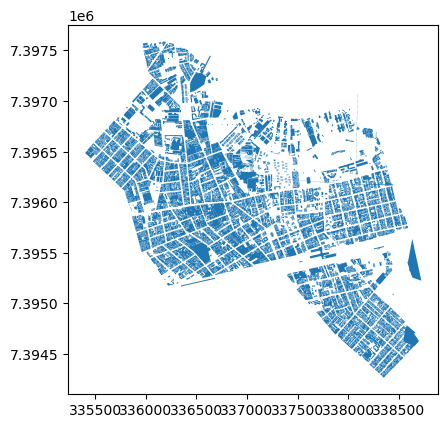

In [37]:
gdf_regularizado.plot()

In [38]:
gdf_regularizado.loc[gdf_regularizado.area > 1.5, colunas_manter].reset_index().to_file(f'results/belem-multipoligono.gpkg', driver='GPKG')

In [39]:
os.remove('temp/BHM-bras.vrt')
os.remove('temp/BHM-bras.tiff')
os.remove('temp/quadras_viarias.tiff')